In [90]:
#Lab 07
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure


# FUNCTIONS ----------------------------------------------------------------------------------------
# Both LoadImage and GetSobelFeatures are from assignment 1: modified a bit
def LoadImage(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.resize(img, size)
    #img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img


def plot_images_grid(images, titles, cols=4, figsize=(12,6), heatmap=False):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(zip(images, titles)):
        plt.subplot(rows, cols, i+1)
        plt.imshow(img, cmap='viridis' if heatmap else 'gray')
        plt.title(title)
        plt.axis("off")
        if heatmap:
            plt.colorbar()
    plt.tight_layout()
    plt.show()

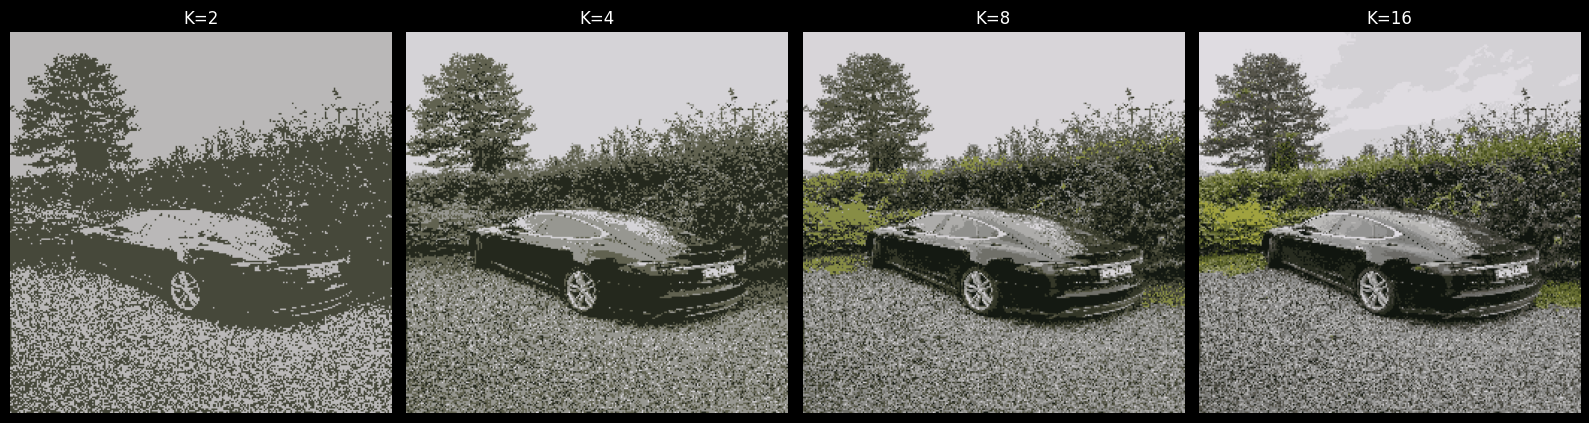

In [91]:
#1, 2 K-Means colour segmentation
img = LoadImage('resized_256x256.jpg')

h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = [2,4,8,16]
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)

clustered_img = []

for k in k_means:
    compactness, labels, centers = cv2.kmeans(
        img,
        k,
        None,
        criteria,
        1,
        cv2.KMEANS_PP_CENTERS
    )
    clustered = centers[labels.flatten()]
    clustered = clustered.reshape(h,w,3).astype(np.uint8)
    clustered_img.append(clustered)

#matplotlib uses rgb, so converted to rgb for display
clustered_RGB = [cv2.cvtColor(k, cv2.COLOR_BGR2RGB) for k in clustered_img]

titles = [f"K={k}" for k in k_means]

plot_images_grid(clustered_RGB, titles, cols=4, figsize=(16,6))



We can see the

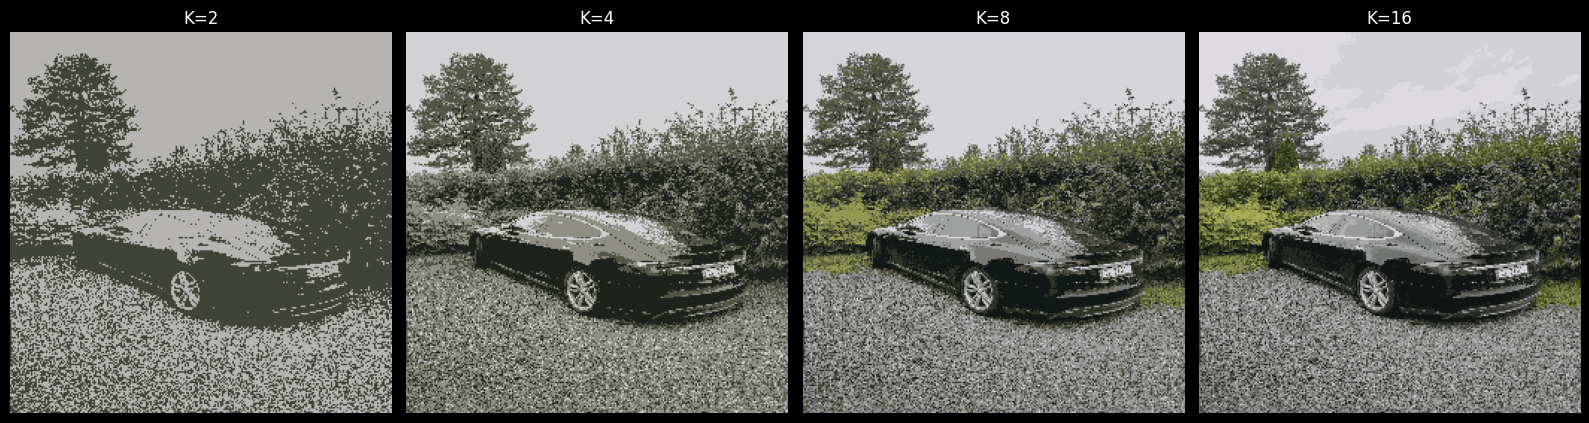

In [92]:
#1 K-Means colour segmentation
img = LoadImage('resized_256x256.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = [2,4,8,16]
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)

clustered_img = []


for k in k_means:
    compactness, labels, centers = cv2.kmeans(
        img,
        k,
        None,
        criteria,
        1,
        cv2.KMEANS_PP_CENTERS
    )
    clustered = centers[labels.flatten()]
    clustered = clustered.reshape(h,w,3).astype(np.uint8)
    clustered_img.append(clustered)

#matplotlib uses rgb, so converted to rgb for display
clustered_RGB = [cv2.cvtColor(k, cv2.COLOR_LAB2RGB) for k in clustered_img]

titles = [f"K={k}" for k in k_means]

plot_images_grid(clustered_RGB, titles, cols=4, figsize=(16,6))

- There is some difference in the sky on the k=16 picture, when calculating in LAB, the sky is more uniform in colour
- when it was calculated in BGR the sky was split into 2 clusters other than that its hard to see the difference
-

In [93]:
#1 K-Means colour segmentation
img = LoadImage('resized_256x256.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = [2,4,8,16]
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)

clustered_img = []
compactness_dict = {}

for k in k_means:
    compactness_list = []
    for i in range(5):
        compactness, labels, centers = cv2.kmeans(
            img,
            k,
            None,
            criteria,
            1,
            cv2.KMEANS_PP_CENTERS
        )
        compactness_list.append(compactness)
        print(f"K:{k}, Run: {i}, Compactness: {compactness:.2f}")
    compactness_dict[k] = compactness_list

#matplotlib uses rgb, so converted to rgb for display
#clustered_RGB = [cv2.cvtColor(k, cv2.COLOR_LAB2RGB) for k in clustered_img]

#titles = [f"K={k}" for k in k_means]

#plot_images_grid(clustered_RGB, titles, cols=4, figsize=(16,6))

K:2, Run: 0, Compactness: 84341059.97
K:2, Run: 1, Compactness: 84313342.57
K:2, Run: 2, Compactness: 84296511.71
K:2, Run: 3, Compactness: 84309728.68
K:2, Run: 4, Compactness: 84325165.46
K:4, Run: 0, Compactness: 23133745.79
K:4, Run: 1, Compactness: 23076599.22
K:4, Run: 2, Compactness: 23133291.41
K:4, Run: 3, Compactness: 23086410.03
K:4, Run: 4, Compactness: 23127580.10
K:8, Run: 0, Compactness: 9911798.19
K:8, Run: 1, Compactness: 9651405.78
K:8, Run: 2, Compactness: 10293076.33
K:8, Run: 3, Compactness: 10561703.00
K:8, Run: 4, Compactness: 9777210.63
K:16, Run: 0, Compactness: 4729571.44
K:16, Run: 1, Compactness: 4968873.59
K:16, Run: 2, Compactness: 4883361.79
K:16, Run: 3, Compactness: 4713388.52
K:16, Run: 4, Compactness: 4772035.60


For small K (2 or 4), K-means is highly consistent: all runs produce nearly identical total within-cluster sums of squared distances. For K=8, one run produced a noticeably higher compactness, indicating sensitivity to initialization. For K=16, the variation is moderate (~2–3%), showing that K-means is generally stable but benefits from multiple initializations at higher K.

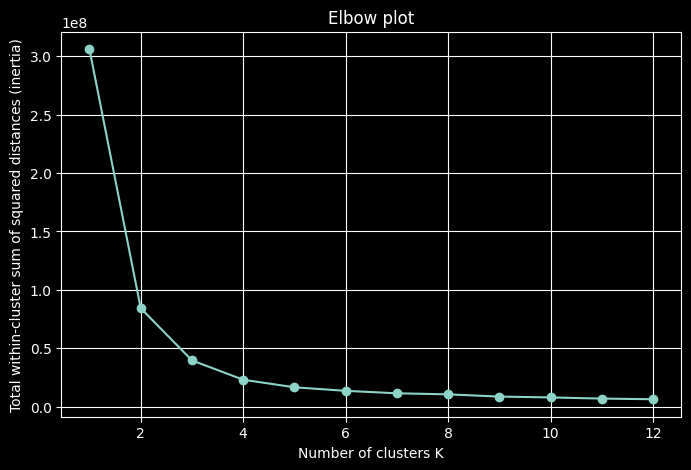

In [94]:
#1 K-Means colour segmentation
img = LoadImage('resized_256x256.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
h,w,c = img.shape
img = img.reshape(-1, 3).astype(np.float32)

k_means = range(1,13)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 1.0)
inertia = []




for k in k_means:


    compactness, labels, centers = cv2.kmeans(
        img,
        k,
        None,
        criteria,
        1,
        cv2.KMEANS_PP_CENTERS
    )
    inertia.append(compactness)

# Plot elbow
plt.figure(figsize=(8,5))
plt.plot(k_means, inertia, marker='o')
plt.xlabel("Number of clusters K")
plt.ylabel("Total within-cluster sum of squared distances (inertia)")
plt.title("Elbow plot")
plt.grid(True)
plt.show()



In [95]:
K_chosen = 4
compactness, labels, centers = cv2.kmeans(
    img,
    K_chosen,
    None,
    criteria,
    10,
    cv2.KMEANS_PP_CENTERS
)

# Centers are Lab colors; convert to RGB for interpretation
centers_rgb = cv2.cvtColor(centers.reshape(-1,1,3).astype(np.uint8), cv2.COLOR_LAB2RGB).reshape(-1,3)
print("Cluster centroids (RGB):")
for i, c in enumerate(centers_rgb):
    print(f"Cluster {i}: {c}")

Cluster centroids (RGB):
Cluster 0: [84 86 70]
Cluster 1: [211 210 212]
Cluster 2: [144 144 135]
Cluster 3: [30 34 28]


K = 4 is a reasonable choice for this image because adding more clusters mostly produces redundant colors, providing little extra information.